# 📝 Task 2 – Telegram Message Loading, Enrichment & Export  
📘 Version: 2025-07-15  

This notebook transforms raw, unstructured Telegram messages into a clean, analytics-ready dataset for **Kara Solutions’ Healthcare Marketplace Intelligence Platform**. It consolidates multi-channel JSON dumps scraped from medical product channels, enriches message content with text, time, and media-derived features, and validates data integrity across views, timestamps, and attachments.

The outputs from this task will feed directly into **semantic vector embedding, object detection (YOLOv8), and dbt-powered dimensional modeling** in downstream tasks.

---

**Challenge:** B5W7 – Shipping a Data Product  
**Company:** Kara Solutions  
**Author:** Nabil Mohamed  
**Branch:** `task-2-load-transform`  
**Date:** July 2025  

---

### 📌 This notebook covers:
- Loading raw Telegram JSON dumps across multiple channels and scrape dates  
- Normalizing message structure and extracting key fields (`message`, `timestamp`, `views`, `media_path`, etc.)  
- Enriching with:
  - Cleaned text  
  - Word and character counts  
  - Temporal metadata (`day_of_week`, `hour_of_day`, `date_id`)  
  - Media file path normalization and existence checks  
- Validating uniqueness, nulls, and structural completeness  
- Exporting a unified dataset to `data/cleaned/telegram_messages_parsed.csv` for downstream use:
  - YOLOv8 image enrichment (Task 3)  
  - dbt star schema modeling (Task 3–4)  
  - FastAPI endpoint integration (Task 4)  


In [1]:
# ------------------------------------------------------------------------------
# 🛠 Ensure Notebook Runs from Project Root (for src/ imports to work)
# ------------------------------------------------------------------------------

import os
import sys

# If running from /notebooks/, move up to project root
if os.path.basename(os.getcwd()) == "notebooks":
    os.chdir("..")
    print("📂 Changed working directory to project root")

# Add project root to sys.path so `src/` modules can be imported
project_root = os.getcwd()
if project_root not in sys.path:
    sys.path.insert(0, project_root)
    print(f"✅ Added to sys.path: {project_root}")

# Optional: verify file presence to confirm we're in the right place
expected_path = "data/raw"
print(
    "📁 Output path ready"
    if os.path.exists(expected_path)
    else f"⚠️ Output path not found: {expected_path}"
)

📂 Changed working directory to project root
✅ Added to sys.path: c:\Users\admin\Documents\GIT Repositories\b5w7-shipping-a-data-product-challenge
📁 Output path ready


## 📦 Imports & Environment Setup

This cell loads the core libraries required for structured data loading, complaint text normalization, temporal enrichment, and data validation in the context of **Telegram complaint ingestion** for intelligent complaint analysis. Imports are grouped by function:

- **Data handling:** `pandas`, `json`, `pathlib`
- **Progress feedback:** `tqdm`
- **Text cleaning:** `re`
- **Date/time analysis:** `datetime`, `pandas.to_datetime`
- **System utilities:** `os`, `warnings`


In [2]:
# ---------------------------
# 📦 Imports & Environment Setup
# ---------------------------

# Data handling
import pandas as pd  # For structured data manipulation
import json  # For loading raw Telegram JSON files
from pathlib import Path  # For robust path handling across OS
from datetime import datetime  # For timestamp parsing and formatting

# Text processing
import re  # For regex-based text cleaning

# Progress and diagnostics
from tqdm import tqdm  # For progress bar during file loading

# System & utilities
import os  # For filesystem operations
import warnings  # To suppress unnecessary warnings

# Configure display settings for clarity
pd.set_option("display.max_columns", None)  # Show all columns when printing DataFrames
pd.set_option("display.float_format", "{:,.2f}".format)  # Consistent float formatting
warnings.filterwarnings("ignore")  # Suppress warnings for cleaner output

## 📊 Preview Enriched Telegram Message Dataset

This step validates the enriched dataset of Telegram medical/commercial posts by displaying key metadata:

- Sample messages and associated channels  
- Word and character count distributions  
- Media attachment availability (`media_exists`)  
- Timestamp formatting integrity (`timestamp`, `day_of_week`, `hour_of_day`)  

This validation ensures that the dataset is clean, structured, and fully ready for:

- 🧠 YOLOv8-based image enrichment  
- 🧱 Star schema modeling with dbt  
- 🔍 Semantic vector embedding and retrieval  


In [3]:
class TelegramMessageLoader:
    """
    Loads and flattens raw Telegram message dumps into a unified DataFrame.

    Assumes each .json file contains a list of messages, each a dict with:
    - 'channel', 'message', 'timestamp', 'views', 'media_path'
    """

    def __init__(self, root_dir: str):
        self.root_dir = Path(root_dir)  # Root directory for Telegram JSONs
        self.records = []  # Accumulate all parsed message records

    def load_all_messages(self):
        """Parses all valid .json message files in nested channel/date structure."""
        try:
            json_files = list(
                self.root_dir.rglob("*.json")
            )  # Recursively find all JSON files
            for file_path in tqdm(json_files, desc="📂 Loading Telegram JSONs"):
                try:
                    with open(file_path, "r", encoding="utf-8") as f:
                        messages = json.load(f)  # Should be a list of dicts
                        if not isinstance(messages, list):
                            print(f"⚠️ Skipped non-list JSON file: {file_path}")
                            continue

                        for msg in messages:
                            if not isinstance(msg, dict) or "message" not in msg:
                                continue  # Skip malformed or blank entries

                            self.records.append(
                                {
                                    "message_id": msg.get("message_id")
                                    or msg.get("id")
                                    or None,  # Optional fallback
                                    "channel": msg.get(
                                        "channel", file_path.parts[-2]
                                    ),  # Use from message or folder
                                    "message": msg.get("message", "").strip(),
                                    "timestamp": msg.get(
                                        "timestamp"
                                    ),  # Already ISO formatted
                                    "views": msg.get("views"),
                                    "media_path": msg.get("media_path"),  # May be None
                                }
                            )
                except Exception as file_error:
                    print(f"❌ Failed to process file: {file_path} — {file_error}")

            df = pd.DataFrame(self.records)  # Convert all rows to a DataFrame

            if df.empty:
                raise ValueError("No valid messages found across all files.")
            if "message" not in df.columns:
                raise ValueError("Missing 'message' field after loading.")

            return df
        except Exception as e:
            raise RuntimeError(f"Failed to load Telegram messages: {e}")

In [4]:
# -------------------------------
# ✨ Class: TelegramMessageEnricher
# -------------------------------


class TelegramMessageEnricher:
    """Cleans and enriches Telegram message DataFrame with useful features."""

    def __init__(self, df: pd.DataFrame, image_root: str):
        self.df = df.copy()  # Work on a copy of the DataFrame
        self.image_root = Path(image_root)  # Base path to Telegram images

    def clean_text(self, text: str):
        """Remove emojis, symbols, extra whitespace."""
        if not isinstance(text, str):
            return ""
        text = re.sub(r"http\S+", "", text)  # Remove URLs
        text = re.sub(r"[^A-Za-z0-9\s.,!?]", "", text)  # Remove special chars/emojis
        return re.sub(r"\s+", " ", text).strip()  # Collapse whitespace

    def enrich(self):
        """Apply all enrichment steps to the DataFrame."""
        try:
            self.df["clean_text"] = self.df["message"].apply(
                self.clean_text
            )  # Cleaned message
            self.df["word_count"] = self.df["clean_text"].apply(
                lambda x: len(x.split())
            )  # Word count
            self.df["char_length"] = self.df["clean_text"].apply(
                len
            )  # Character length

            self.df["timestamp"] = pd.to_datetime(
                self.df["timestamp"], errors="coerce"
            )  # Convert timestamp
            self.df["date_id"] = self.df["timestamp"].dt.strftime(
                "%Y-%m-%d"
            )  # Format date
            self.df["day_of_week"] = self.df["timestamp"].dt.day_name()  # Day of week
            self.df["hour_of_day"] = self.df["timestamp"].dt.hour  # Hour of day

            self.df["media_full_path"] = self.df.apply(
                lambda row: (
                    self.image_root
                    / row["date_id"]
                    / row["channel"]
                    / row["media_path"]
                    if pd.notnull(row["media_path"])
                    else None
                ),
                axis=1,
            )

            self.df["media_exists"] = self.df["media_full_path"].apply(
                lambda p: p.exists() if isinstance(p, Path) else False
            )

            return self.df
        except Exception as e:
            raise RuntimeError(f"Enrichment failed: {e}")

In [7]:
# -------------------------------
# ✅ Load → Enrich → Validate → Export
# -------------------------------

# Step 1: Load messages
loader = TelegramMessageLoader(root_dir="data/raw/telegram_messages")
raw_df = loader.load_all_messages()

# Step 2: Enrich messages
enricher = TelegramMessageEnricher(df=raw_df, image_root="data/raw/telegram_images")
enriched_df = enricher.enrich()

# Step 3: Validate
print("🔍 Validation Checks:")
print(f" - Total messages: {len(enriched_df)}")
print(f" - Unique IDs: {enriched_df['message_id'].nunique()}")
print(f" - Null message count: {enriched_df['message'].isnull().sum()}")
print(f" - Media missing: {enriched_df['media_exists'].value_counts(dropna=False)}")

# Step 4: Export
Path("data/cleaned").mkdir(parents=True, exist_ok=True)  # Create folder if missing
export_path = "data/cleaned/telegram_messages_parsed.csv"
enriched_df.to_csv(export_path, index=False)
print(f"✅ Exported enriched dataset to: {export_path}")

📂 Loading Telegram JSONs: 100%|██████████| 3/3 [00:00<00:00, 53.09it/s]


🔍 Validation Checks:
 - Total messages: 951
 - Unique IDs: 0
 - Null message count: 0
 - Media missing: media_exists
True     649
False    302
Name: count, dtype: int64
✅ Exported enriched dataset to: data/cleaned/telegram_messages_parsed.csv


In [6]:
import json

with open(
    "data/raw/telegram_messages/2025-07-15/lobelia4cosmetics/lobelia4cosmetics_2025-07-15.json",
    "r",
    encoding="utf-8",
) as f:
    data = json.load(f)

print(type(data))
print("messages" in data if isinstance(data, dict) else "raw list")
print(data[:1] if isinstance(data, list) else data.get("messages", [])[:1])

<class 'list'>
raw list
[{'channel': 'lobelia4cosmetics', 'message': 'CINNAMON TOAST CRUSHE\nPrice 3400 birr \nTelegram @Lobeliacosmetics\nMsg👉 Lobelia pharmacy and cosmetics \n☎️ call 0911562031/0911587703\nAdress:- Infront of Bole Medhanialem high school ALEMNESH PLAZA GROUND FLOOR \nOpen Monday - Monday from 8am until midnight ከሰኞ - እስከ ሰኞ\xa0 ከጧቱ 2:00 ስዓት - እስከ ምሽቱ 6:00 ሰዓት\n🏍🏍🏍 የትራንስፖርት አማራጭ ከ70 - 500 ብር\nFor delivery option fees are from 70 birr - 500 birr', 'views': 502, 'timestamp': '2025-07-15T15:04:23+00:00', 'has_media': True, 'media_path': 'c:\\Users\\admin\\Documents\\GIT Repositories\\b5w7-shipping-a-data-product-challenge\\data\\raw\\telegram_images\\2025-07-15\\lobelia4cosmetics\\photo_2025-07-15_15-04-23 (1).jpg'}]


## 1. Distribution of Word Count per Message

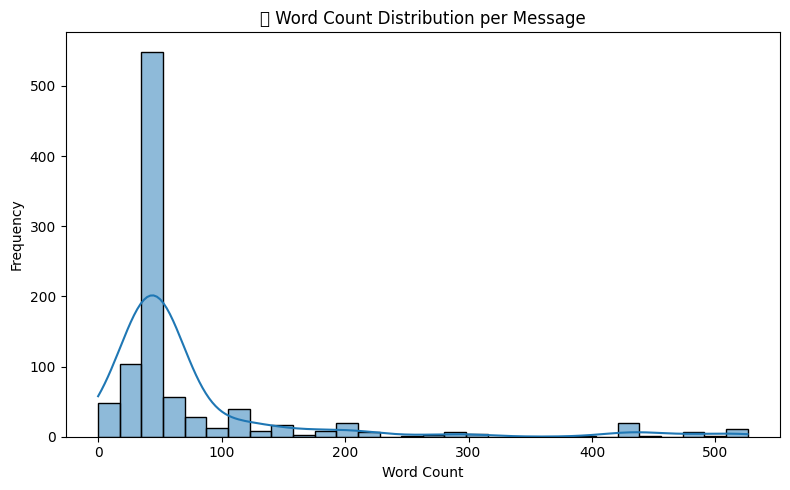

In [8]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(8, 5))
sns.histplot(enriched_df["word_count"], bins=30, kde=True)
plt.title("📝 Word Count Distribution per Message")
plt.xlabel("Word Count")
plt.ylabel("Frequency")
plt.tight_layout()
plt.show()

## 2. Message Volume by Day of Week

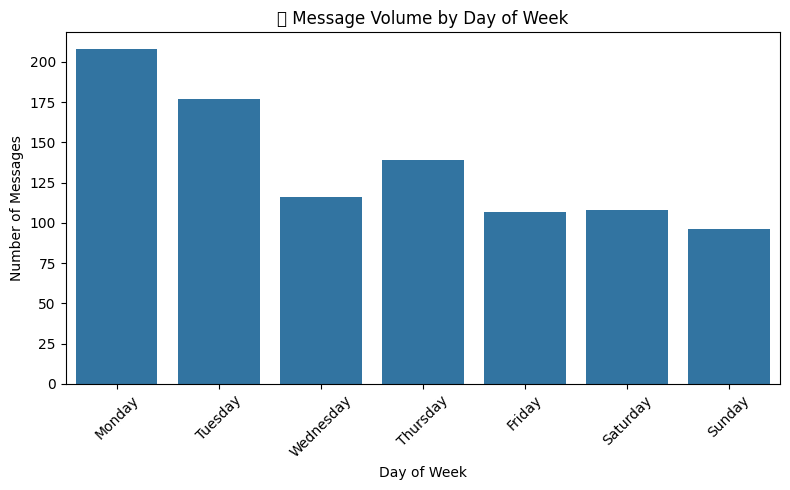

In [9]:
plt.figure(figsize=(8, 5))
sns.countplot(
    data=enriched_df,
    x="day_of_week",
    order=[
        "Monday",
        "Tuesday",
        "Wednesday",
        "Thursday",
        "Friday",
        "Saturday",
        "Sunday",
    ],
)
plt.title("📅 Message Volume by Day of Week")
plt.xlabel("Day of Week")
plt.ylabel("Number of Messages")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

## 3. Media Attachment Presence

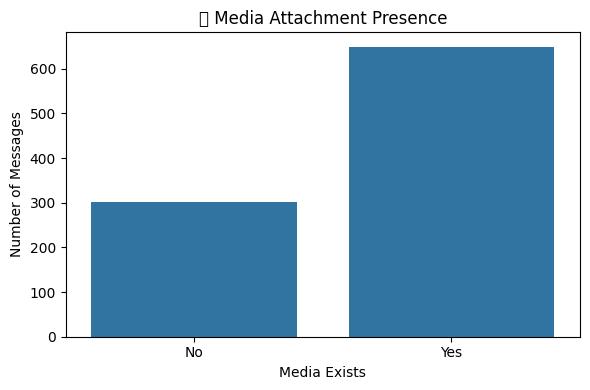

In [10]:
plt.figure(figsize=(6, 4))
sns.countplot(data=enriched_df, x="media_exists")
plt.title("🖼 Media Attachment Presence")
plt.xlabel("Media Exists")
plt.ylabel("Number of Messages")
plt.xticks([0, 1], ["No", "Yes"])
plt.tight_layout()
plt.show()

## 4. Hourly Message Frequency

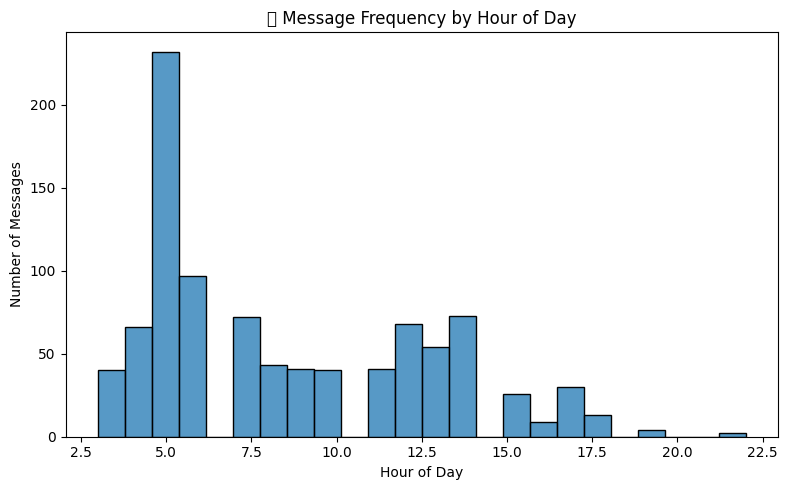

In [11]:
plt.figure(figsize=(8, 5))
sns.histplot(enriched_df["hour_of_day"], bins=24, kde=False)
plt.title("⏰ Message Frequency by Hour of Day")
plt.xlabel("Hour of Day")
plt.ylabel("Number of Messages")
plt.tight_layout()
plt.show()